## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Cleaned Dataset

In [2]:
cleaned_path = r"C:\Users\admin\Downloads\cleaned_health_dataset1.csv"

df = pd.read_csv(cleaned_path)

print("Shape:", df.shape)
df.head()

Shape: (5200, 53)


,Person_ID,Age,Gender,Ethnicity,Education_Level,Income_Level,Occupation,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,Junk_Food_Frequency_Per_Week,Fast_Food_Meals_Per_Week,Sugary_Drinks_Per_Week,Processed_Food_Intake,Snack_Frequency_Per_Day,Daily_Calorie_Intake,Fruit_Servings_Per_Day,Vegetable_Servings_Per_Day,Whole_Grain_Intake,Protein_Source,Water_Intake_Liters,Healthy_Food_Score,Daily_Sugar_g,Daily_Sodium_mg,Fiber_g,Saturated_Fat_g,Protein_g,Physical_Activity_Minutes_Per_Day,Exercise_Frequency_Per_Week,Sleep_Hours,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_Diabetes,Family_History_Heart_Disease,Existing_Conditions,Medication_Use,Blood_Pressure,Fasting_Glucose_mg_dL,HbA1c_Percent,Cholesterol_Total_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Urban_Rural,Food_Accessibility_Score,Screen_Time_Hours_Per_Day,10_Year_Diabetes_Risk_Percent,10_Year_CVD_Risk_Percent,10_Year_Obesity_Risk_Percent,Health_Risk_Category
0,P00001,19,Female,White,Middle School,Low,Student,162.2,61.8,23.5,65.9,33.9,6,0,7,Low,2,1806,0.0,0.7,Low,Poultry,2.3,0.0,300.0,929,1.0,15.9,50.9,17,1,8.0,Moderate,Never,Occasional,Yes,No,Asthma,Inhaler,90/55,124.9,5.4,151,75,40,384,Suburban,35.4,5.8,60.3,28.6,43.7,Moderate
1,P00002,16,Male,Asian,High School,High,Student,181.4,56.6,17.2,55.0,13.1,3,1,1,Moderate,2,1558,0.7,0.4,Unknown,Mixed,7.5,8.6,123.3,2006,2.4,14.8,73.9,26,1,7.6,Low,Never,Moderate,No,No,No Known Condition,NaN,90/55,94.0,5.1,193,77,87,203,Urban,90.2,2.5,25.6,24.7,9.8,Low
2,P00003,17,Male,White,High School,Low,Student,170.2,69.5,24.0,56.2,21.6,7,1,4,Moderate,2,1352,3.2,0.1,Unknown,Mixed,4.2,5.4,266.4,1837,6.9,22.4,58.4,27,1,5.2,Moderate,Never,Occasional,Yes,No,Pre-Diabetes,NaN,106/70,128.8,6.2,213,53,104,315,Suburban,38.5,3.9,60.8,41.0,26.4,Moderate
3,P00004,19,Male,White,Middle School,High,Student,169.8,87.4,30.3,71.0,27.7,1,0,2,Low,1,1552,2.1,4.3,Low,Red Meat,4.1,40.2,105.2,1131,18.1,12.8,65.4,16,1,7.6,Low,Never,Non-Drinker,No,No,No Known Condition,NaN,126/77,136.3,6.2,176,60,72,250,Suburban,88.3,3.1,37.8,29.3,45.3,Moderate
4,P00005,15,Male,Hispanic,High School,Middle,Student Athlete,177.8,77.1,24.4,57.4,18.1,3,2,3,Moderate,2,1809,1.3,1.8,Low,Fish,8.0,24.0,168.6,2492,8.7,13.4,92.2,110,4,8.0,High,Regular,Moderate,Yes,No,No Known Condition,NaN,112/74,109.1,5.5,210,79,88,270,Rural,79.7,1.3,33.1,40.7,30.6,Moderate


## 3. Feature Engineering — Blood Pressure

In [3]:
# Convert Blood_Pressure from text such as 120/80 into numeric features
df[['Systolic_BP', 'Diastolic_BP']] = (
    df['Blood_Pressure']
    .str.split('/', expand=True)
    .astype(float)
)

print(df[['Blood_Pressure', 'Systolic_BP', 'Diastolic_BP']].head())

  Blood_Pressure  Systolic_BP  Diastolic_BP
0          90/55         90.0          55.0
1          90/55         90.0          55.0
2         106/70        106.0          70.0
3         126/77        126.0          77.0
4         112/74        112.0          74.0


In [4]:
def bp_category(sys, dia):
    if sys < 120 and dia < 80:
        return 'Normal'
    elif 120 <= sys < 130 and dia < 80:
        return 'Elevated'
    elif sys >= 130 or dia >= 80:
        return 'High'
    return 'Unknown'

df['BP_Category'] = df.apply(
    lambda x: bp_category(x['Systolic_BP'], x['Diastolic_BP']),
    axis=1
)

df = df.drop(columns='Blood_Pressure')


## 4. Feature Engineering — BMI Category

In [5]:
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 60],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df['BMI_Category'].value_counts()

BMI_Category
Normal         2428
Overweight     1344
Obese           895
Underweight     533
Name: count, dtype: int64

## 5. Feature Distribution and Skewness Check

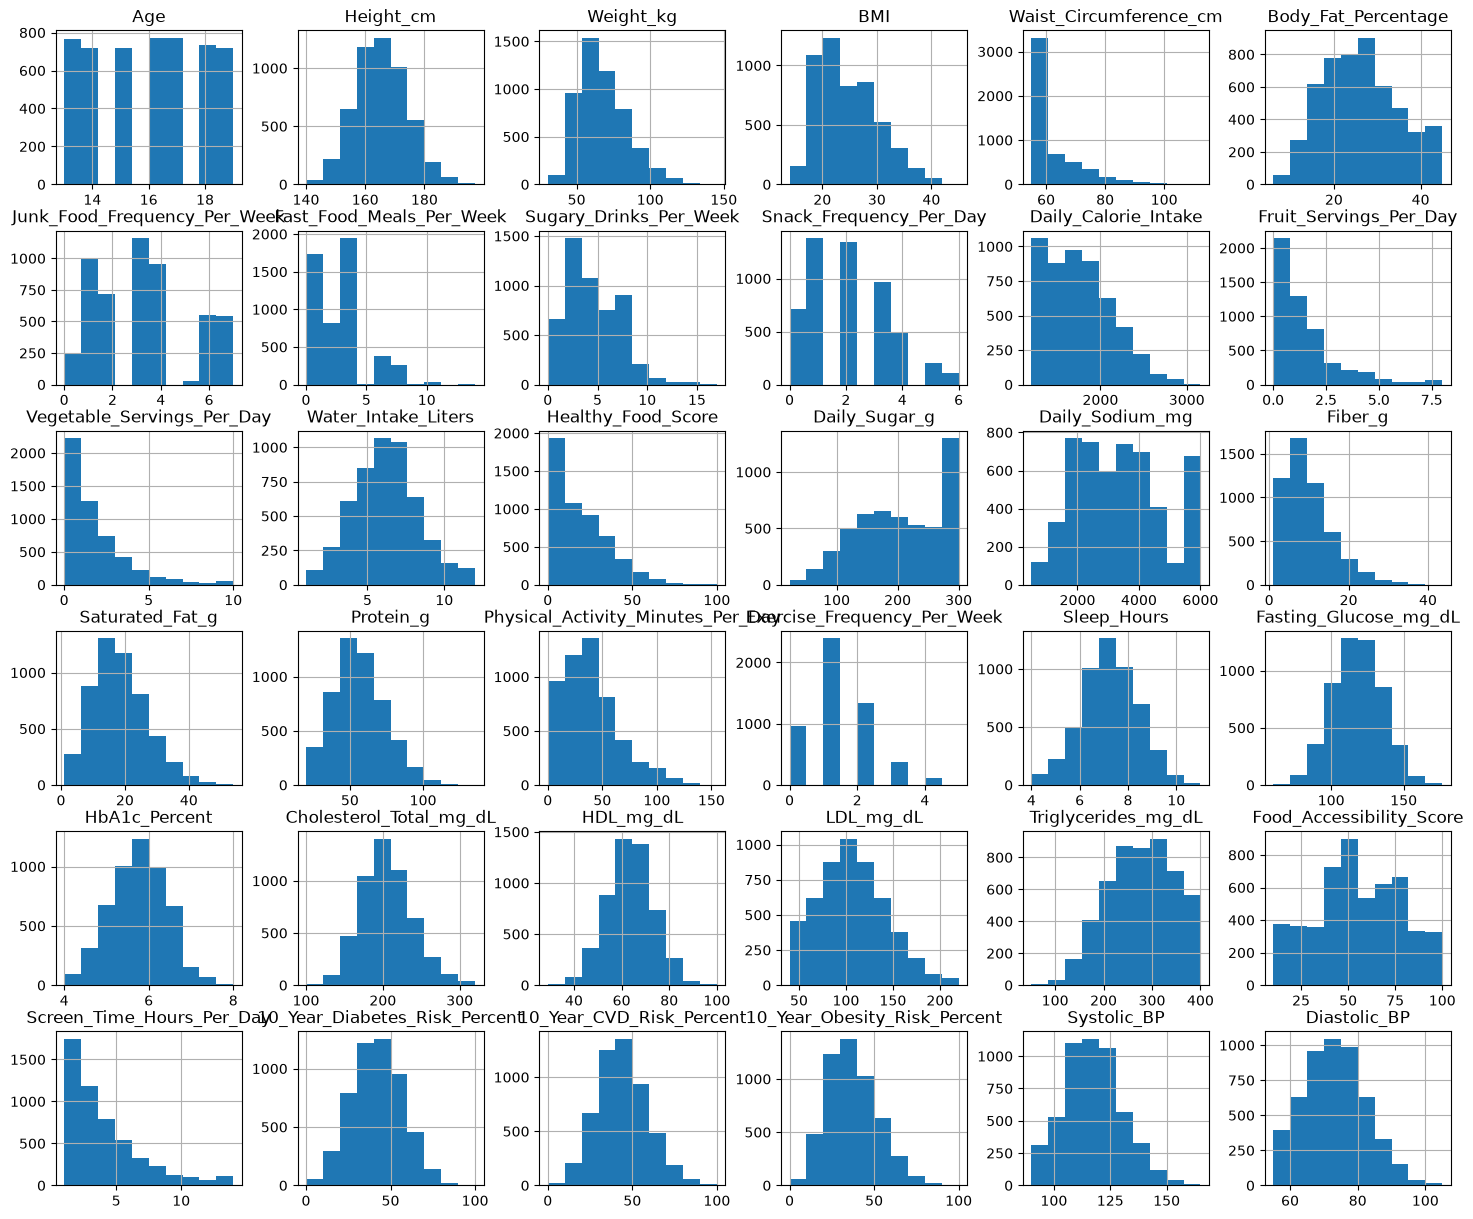

In [6]:
df.hist(figsize=(18, 15))
plt.show()

In [7]:
num_cols = df.select_dtypes(include="number")
num_cols.skew()

Age                                 -0.008921
Height_cm                            0.170281
Weight_kg                            0.766069
BMI                                  0.629313
Waist_Circumference_cm               1.612996
Body_Fat_Percentage                  0.282289
Junk_Food_Frequency_Per_Week         0.428401
Fast_Food_Meals_Per_Week             1.061692
Sugary_Drinks_Per_Week               0.695158
Snack_Frequency_Per_Day              0.591199
Daily_Calorie_Intake                 0.465969
Fruit_Servings_Per_Day               1.872895
Vegetable_Servings_Per_Day           1.879518
Water_Intake_Liters                  0.196092
Healthy_Food_Score                   0.961393
Daily_Sugar_g                       -0.190012
Daily_Sodium_mg                      0.372378
Fiber_g                              1.108750
Saturated_Fat_g                      0.598157
Protein_g                            0.448436
Physical_Activity_Minutes_Per_Day    0.861072
Exercise_Frequency_Per_Week       

## 6. Final Feature-Engineering Check

In [8]:
df.head()
df.info()
print("Shape:", df.shape)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 56 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Person_ID                          5200 non-null   str     
 1   Age                                5200 non-null   int64   
 2   Gender                             5200 non-null   str     
 3   Ethnicity                          5200 non-null   str     
 4   Education_Level                    5200 non-null   str     
 5   Income_Level                       5200 non-null   str     
 6   Occupation                         5200 non-null   str     
 7   Height_cm                          5200 non-null   float64 
 8   Weight_kg                          5200 non-null   float64 
 9   BMI                                5200 non-null   float64 
 10  Waist_Circumference_cm             5200 non-null   float64 
 11  Body_Fat_Percentage                5200 non-null   flo

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,Junk_Food_Frequency_Per_Week,Fast_Food_Meals_Per_Week,Sugary_Drinks_Per_Week,Snack_Frequency_Per_Day,Daily_Calorie_Intake,Fruit_Servings_Per_Day,Vegetable_Servings_Per_Day,Water_Intake_Liters,Healthy_Food_Score,Daily_Sugar_g,Daily_Sodium_mg,Fiber_g,Saturated_Fat_g,Protein_g,Physical_Activity_Minutes_Per_Day,Exercise_Frequency_Per_Week,Sleep_Hours,Fasting_Glucose_mg_dL,HbA1c_Percent,Cholesterol_Total_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Food_Accessibility_Score,Screen_Time_Hours_Per_Day,10_Year_Diabetes_Risk_Percent,10_Year_CVD_Risk_Percent,10_Year_Obesity_Risk_Percent,Systolic_BP,Diastolic_BP
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,15.986923,165.399596,67.682288,24.679558,61.224981,26.247192,3.260769,2.744423,4.507692,2.033077,1752.069038,1.473500,1.749462,6.201192,18.957962,205.307385,3369.745769,9.826423,18.328635,56.355981,38.868462,1.290192,7.191115,117.995154,5.714500,204.717115,63.626538,106.595192,277.091154,55.297712,4.004058,42.104788,43.862038,37.237615,117.154808,72.693654
std,1.993600,8.792528,16.600609,5.445403,9.054833,8.809046,2.022493,2.008509,2.653979,1.431000,383.673338,1.526129,1.789249,2.141856,17.113234,71.340380,1419.070373,6.169403,8.461422,17.637812,26.190691,0.933353,1.170306,17.087402,0.666854,33.567102,9.518154,36.509277,68.788232,22.505966,2.837909,14.928660,14.975727,14.553714,12.868865,9.233283
min,13.000000,140.000000,30.400000,14.000000,55.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1200.000000,0.000000,0.000000,1.000000,0.000000,22.900000,500.000000,1.000000,1.000000,20.000000,0.000000,0.000000,4.000000,60.000000,4.000000,100.000000,29.000000,40.000000,51.000000,10.200000,1.000000,0.000000,0.000000,0.000000,90.000000,55.000000
25%,14.000000,159.400000,55.100000,20.300000,55.000000,19.400000,2.000000,1.000000,3.000000,1.000000,1453.000000,0.400000,0.500000,4.700000,3.600000,148.800000,2208.000000,5.400000,12.200000,44.000000,21.000000,1.000000,6.400000,106.100000,5.300000,181.000000,57.000000,80.000000,226.000000,40.700000,1.900000,31.500000,33.500000,26.400000,108.000000,66.000000
50%,16.000000,165.100000,64.900000,23.700000,55.000000,25.800000,3.000000,3.000000,4.000000,2.000000,1724.000000,1.000000,1.200000,6.150000,16.300000,204.500000,3271.000000,8.700000,17.400000,55.000000,35.000000,1.000000,7.200000,118.000000,5.700000,203.000000,64.000000,105.000000,279.000000,53.800000,3.100000,41.900000,43.000000,35.500000,117.000000,72.000000
75%,18.000000,171.300000,78.000000,28.400000,65.600000,32.200000,4.000000,4.000000,6.000000,3.000000,2007.000000,2.000000,2.400000,7.600000,29.400000,272.250000,4245.250000,13.000000,23.400000,67.700000,53.000000,2.000000,8.000000,129.900000,6.200000,226.000000,70.000000,130.000000,330.000000,73.200000,5.200000,52.325000,53.500000,46.900000,126.000000,79.000000
max,19.000000,197.100000,145.300000,45.000000,112.300000,45.000000,7.000000,14.000000,17.000000,6.000000,3159.000000,8.000000,10.000000,12.000000,100.000000,300.000000,6000.000000,43.600000,53.900000,135.500000,155.000000,5.000000,11.000000,176.600000,8.000000,320.000000,100.000000,220.000000,400.000000,100.000000,14.000000,100.000000,100.000000,100.000000,165.000000,105.000000


## 7. Encode Target

In [9]:
mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

df['Health_Risk_Category'] = df['Health_Risk_Category'].map(mapping)

## 8. Ordinal Encoding

These variables have an order, so the original notebook mapped them to ordered numerical values.

In [10]:
education_map = {
    'Middle School': 0,
    'High School': 1,
    'Some College': 2
}

income_map = {
    'Low': 0,
    'Middle': 1,
    'High': 2
}

processed_food_map = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

whole_grain_map = {
    'Unknown': 0,
    'Low': 1,
    'Moderate': 2,
    'High': 3
}

stress_map = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

alcohol_map = {
    'Non-Drinker': 0,
    'Occasional': 1,
    'Moderate': 2,
    'Heavy': 3
}

bp_map = {
    'Normal': 0,
    'Elevated': 1,
    'High': 2
}

bmi_map = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3
}

df['Education_Level'] = df['Education_Level'].map(education_map)
df['Income_Level'] = df['Income_Level'].map(income_map)
df['Processed_Food_Intake'] = df['Processed_Food_Intake'].map(processed_food_map)
df['Whole_Grain_Intake'] = df['Whole_Grain_Intake'].map(whole_grain_map)
df['Stress_Level'] = df['Stress_Level'].map(stress_map)
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].map(alcohol_map)
df['BP_Category'] = df['BP_Category'].map(bp_map)
df['BMI_Category'] = df['BMI_Category'].map(bmi_map)

## 9. Binary Encoding

In [11]:
binary_cols = [
    'Gender',
    'Family_History_Diabetes',
    'Family_History_Heart_Disease'
]

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

df['Family_History_Diabetes'] = df['Family_History_Diabetes'].map({
    'No': 0,
    'Yes': 1
})

df['Family_History_Heart_Disease'] = df['Family_History_Heart_Disease'].map({
    'No': 0,
    'Yes': 1
})

## 10. One-Hot Encoding

Nominal variables do not have a natural order, so one-hot encoding is used.

In [12]:
nominal_cols = [
    'Ethnicity',
    'Occupation',
    'Protein_Source',
    'Smoking_Status',
    'Existing_Conditions',
    'Medication_Use',
    'Urban_Rural'
]

df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True
)

## 11. Check Encoded Dataset

In [13]:
print("Shape:", df.shape)
print(df.dtypes.value_counts())
df.head()

Shape: (5200, 71)
int64       24
float64     23
bool        22
str          1
category     1
Name: count, dtype: int64


,Person_ID,Age,Gender,Education_Level,Income_Level,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,Junk_Food_Frequency_Per_Week,Fast_Food_Meals_Per_Week,Sugary_Drinks_Per_Week,Processed_Food_Intake,Snack_Frequency_Per_Day,Daily_Calorie_Intake,Fruit_Servings_Per_Day,Vegetable_Servings_Per_Day,Whole_Grain_Intake,Water_Intake_Liters,Healthy_Food_Score,Daily_Sugar_g,Daily_Sodium_mg,Fiber_g,Saturated_Fat_g,Protein_g,Physical_Activity_Minutes_Per_Day,Exercise_Frequency_Per_Week,Sleep_Hours,Stress_Level,Alcohol_Consumption,Family_History_Diabetes,Family_History_Heart_Disease,Fasting_Glucose_mg_dL,HbA1c_Percent,Cholesterol_Total_mg_dL,HDL_mg_dL,LDL_mg_dL,Triglycerides_mg_dL,Food_Accessibility_Score,Screen_Time_Hours_Per_Day,10_Year_Diabetes_Risk_Percent,10_Year_CVD_Risk_Percent,10_Year_Obesity_Risk_Percent,Health_Risk_Category,Systolic_BP,Diastolic_BP,BP_Category,BMI_Category,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_Other,Ethnicity_White,Occupation_Student,Occupation_Student Athlete,Protein_Source_Mixed,Protein_Source_Plant-Based,Protein_Source_Poultry,Protein_Source_Red Meat,Smoking_Status_Occasional,Smoking_Status_Regular,Existing_Conditions_Hypertension,Existing_Conditions_No Known Condition,Existing_Conditions_Obesity,Existing_Conditions_PCOS,Existing_Conditions_Pre-Diabetes,Medication_Use_Inhaler,Medication_Use_Metformin,Medication_Use_Supplements,Urban_Rural_Suburban,Urban_Rural_Urban
0,P00001,19,0,0,0,162.2,61.8,23.5,65.9,33.9,6,0,7,0,2,1806,0.0,0.7,1,2.3,0.0,300.0,929,1.0,15.9,50.9,17,1,8.0,1,1,1,0,124.9,5.4,151,75,40,384,35.4,5.8,60.3,28.6,43.7,1,90.0,55.0,0,1,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
1,P00002,16,1,1,2,181.4,56.6,17.2,55.0,13.1,3,1,1,1,2,1558,0.7,0.4,0,7.5,8.6,123.3,2006,2.4,14.8,73.9,26,1,7.6,0,2,0,0,94.0,5.1,193,77,87,203,90.2,2.5,25.6,24.7,9.8,0,90.0,55.0,0,0,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
2,P00003,17,1,1,0,170.2,69.5,24.0,56.2,21.6,7,1,4,1,2,1352,3.2,0.1,0,4.2,5.4,266.4,1837,6.9,22.4,58.4,27,1,5.2,1,1,1,0,128.8,6.2,213,53,104,315,38.5,3.9,60.8,41.0,26.4,1,106.0,70.0,0,1,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
3,P00004,19,1,0,2,169.8,87.4,30.3,71.0,27.7,1,0,2,0,1,1552,2.1,4.3,1,4.1,40.2,105.2,1131,18.1,12.8,65.4,16,1,7.6,0,0,0,0,136.3,6.2,176,60,72,250,88.3,3.1,37.8,29.3,45.3,1,126.0,77.0,1,3,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False
4,P00005,15,1,1,1,177.8,77.1,24.4,57.4,18.1,3,2,3,1,2,1809,1.3,1.8,1,8.0,24.0,168.6,2492,8.7,13.4,92.2,110,4,8.0,2,2,1,0,109.1,5.5,210,79,88,270,79.7,1.3,33.1,40.7,30.6,1,112.0,74.0,0,1,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False


## 12. Save Feature-Engineered Dataset

In [14]:
feature_path = r"C:\Users\admin\Downloads\feature_engineered_health_dataset.csv"

df.to_csv(feature_path, index=False)

print("Saved:", feature_path)

Saved: C:\Users\admin\Downloads\feature_engineered_health_dataset.csv
